In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import BallTree
from collections import defaultdict

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
viirs_night = pd.read_csv(
    "viirs_night_2023_2024_eda.csv"
)

viirs_night["acq_date"] = pd.to_datetime(
    viirs_night["acq_date"],
    errors="coerce"
)

print("Shape:", viirs_night.shape)
print(
    "Date range:",
    viirs_night["acq_date"].min().date(),
    "to",
    viirs_night["acq_date"].max().date()
)

Shape: (323659, 18)
Date range: 2023-01-01 to 2024-12-31


In [3]:
events = viirs_night[
    [
        "latitude",
        "longitude",
        "acq_date",
        "acq_time",
        "bright_ti4",
        "bright_ti5",
        "frp",
        "confidence",
        "type"
    ]
].copy()

events = events.dropna(
    subset=["latitude", "longitude", "acq_date"]
).reset_index(drop=True)

print("Working observations:", len(events))

Working observations: 323659


In [4]:
events["detection_id"] = np.arange(len(events))

events.head()

,latitude,longitude,acq_date,acq_time,bright_ti4,bright_ti5,frp,confidence,type,detection_id
0,27.3208,95.2657,2023-01-01,1834,297.9700,281.1800,2.7700,n,0,0
1,27.3206,95.2670,2023-01-01,1834,295.1700,281.3900,1.7100,n,0,1
2,26.0624,93.9271,2023-01-01,1834,295.7500,282.5500,0.7000,n,0,2
3,31.0857,77.8079,2023-01-01,2014,310.1700,276.5000,3.0200,n,0,3
4,27.4625,95.4766,2023-01-01,2014,303.1100,280.7800,0.6900,n,2,4


In [5]:
EARTH_RADIUS_KM = 6371.0088

coords_rad = np.radians(
    events[
        ["latitude", "longitude"]
    ].values
)

print("Coordinate matrix:", coords_rad.shape)

Coordinate matrix: (323659, 2)


In [6]:
tree = BallTree(
    coords_rad,
    metric="haversine"
)

print("Spatial index created.")

Spatial index created.


In [7]:
SPATIAL_RADIUS_KM = 1.0

SPATIAL_RADIUS_RAD = (
    SPATIAL_RADIUS_KM / EARTH_RADIUS_KM
)

print(
    "Candidate spatial radius:",
    SPATIAL_RADIUS_KM,
    "km"
)

Candidate spatial radius: 1.0 km


In [8]:
neighbour_lists = tree.query_radius(
    coords_rad,
    r=SPATIAL_RADIUS_RAD
)

print(
    "Neighbourhoods generated:",
    len(neighbour_lists)
)

Neighbourhoods generated: 323659


In [9]:
TEMPORAL_GAP_DAYS = 3

print(
    "Candidate temporal gap:",
    TEMPORAL_GAP_DAYS,
    "days"
)

Candidate temporal gap: 3 days


In [10]:
TEMPORAL_GAP_DAYS = 3

print(
    "Candidate temporal gap:",
    TEMPORAL_GAP_DAYS,
    "days"
)

Candidate temporal gap: 3 days


In [49]:
parent = np.arange(len(events), dtype=np.int32)
size = np.ones(len(events), dtype=np.int32)


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(a, b):
    root_a = find(a)
    root_b = find(b)

    if root_a == root_b:
        return

    if size[root_a] < size[root_b]:
        root_a, root_b = root_b, root_a

    parent[root_b] = root_a
    size[root_a] += size[root_b]

In [50]:
events["date_only"] = events["acq_date"].dt.normalize()

date_groups = {
    pd.Timestamp(date): group.index.to_numpy()
    for date, group in events.groupby("date_only")
}

unique_dates = sorted(date_groups.keys())

print("Unique dates:", len(unique_dates))

Unique dates: 707


In [51]:
SPATIAL_RADIUS_KM = 1.0
TEMPORAL_GAP_DAYS = 3

radius_rad = (
    SPATIAL_RADIUS_KM / EARTH_RADIUS_KM
)

total_connections = 0
processed_observations = 0

for current_date in unique_dates:

    current_indices = date_groups[current_date]

    comparison_indices = []

    for d in range(TEMPORAL_GAP_DAYS + 1):

        comparison_date = (
            current_date
            - pd.Timedelta(days=d)
        )

        if comparison_date in date_groups:
            comparison_indices.append(
                date_groups[comparison_date]
            )

    candidate_indices = np.concatenate(
        comparison_indices
    )

    # Coordinates for candidate observations
    candidate_coords = np.radians(
        events.loc[
            candidate_indices,
            ["latitude", "longitude"]
        ].values
    )

    # Coordinates for current-day observations
    current_coords = np.radians(
        events.loc[
            current_indices,
            ["latitude", "longitude"]
        ].values
    )

    window_tree = BallTree(
        candidate_coords,
        metric="haversine"
    )

    neighbours = window_tree.query_radius(
        current_coords,
        r=radius_rad
    )

    for local_i, local_neighbours in enumerate(neighbours):

        global_i = current_indices[local_i]

        for local_j in local_neighbours:

            global_j = candidate_indices[local_j]

            # Never connect an observation to itself
            if global_i == global_j:
                continue

            union(global_i, global_j)

            total_connections += 1

    processed_observations += len(current_indices)

    if (
        processed_observations % 25000
        < len(current_indices)
    ):
        print(
            f"Processed "
            f"{processed_observations:,} / "
            f"{len(events):,}"
        )

print("\nCompleted.")
print(
    "Spatial-temporal links processed:",
    total_connections
)

Processed 25,233 / 323,659
Processed 53,274 / 323,659
Processed 75,223 / 323,659
Processed 104,587 / 323,659
Processed 125,178 / 323,659
Processed 150,287 / 323,659
Processed 175,038 / 323,659
Processed 200,564 / 323,659
Processed 226,866 / 323,659
Processed 251,323 / 323,659
Processed 275,110 / 323,659
Processed 300,311 / 323,659

Completed.
Spatial-temporal links processed: 1527307


In [52]:
roots = np.array(
    [find(i) for i in range(len(events))],
    dtype=np.int32
)

event_ids = pd.factorize(roots)[0] + 1

events["event_id"] = event_ids

print(
    "Candidate thermal events:",
    events["event_id"].nunique()
)

Candidate thermal events: 102289


In [53]:
event_check = (
    events
    .groupby("event_id")
    .agg(
        start_date=("acq_date", "min"),
        end_date=("acq_date", "max"),
        active_days=("acq_date", "nunique"),
        detections=("detection_id", "count")
    )
)

event_check["duration_days"] = (
    event_check["end_date"]
    - event_check["start_date"]
).dt.days + 1

display(
    event_check.describe()
)

,start_date,end_date,active_days,detections,duration_days
count,102289,102289,102289.0000,102289.0000,102289.0000
mean,2023-10-25 15:28:55.259900928,2023-10-26 10:27:51.241286656,1.5973,3.1642,1.7909
min,2023-01-01 00:00:00,2023-01-01 00:00:00,1.0000,1.0000,1.0000
25%,2023-04-01 00:00:00,2023-04-02 00:00:00,1.0000,1.0000,1.0000
50%,2023-12-21 00:00:00,2023-12-23 00:00:00,1.0000,1.0000,1.0000
75%,2024-04-18 00:00:00,2024-04-18 00:00:00,1.0000,2.0000,1.0000
max,2024-12-31 00:00:00,2024-12-31 00:00:00,160.0000,3133.0000,182.0000
std,NaN,NaN,3.7877,23.0985,4.6311


In [54]:
print(
    "Events spanning >1 day:",
    (event_check["duration_days"] > 1).sum()
)

print(
    "Events with >1 active day:",
    (event_check["active_days"] > 1).sum()
)

print(
    "Maximum event duration:",
    event_check["duration_days"].max()
)

Events spanning >1 day: 17510
Events with >1 active day: 17510
Maximum event duration: 182


In [55]:
roots = np.array(
    [find(i) for i in range(len(events))],
    dtype=np.int32
)

event_ids = pd.factorize(
    roots
)[0] + 1

events["event_id"] = event_ids

print(
    "Candidate thermal events:",
    events["event_id"].nunique()
)

Candidate thermal events: 102289


In [56]:
event_sizes = (
    events
    .groupby("event_id")
    .size()
)

print(event_sizes.describe())

count   102289.0000
mean         3.1642
std         23.0985
min          1.0000
25%          1.0000
50%          1.0000
75%          2.0000
max       3133.0000
dtype: float64


In [57]:
singleton_count = (
    event_sizes == 1
).sum()

total_events = len(event_sizes)

print("Total candidate events:", total_events)
print("Singleton events:", singleton_count)
print(
    "Singleton percentage:",
    round(
        singleton_count / total_events * 100,
        2
    ),
    "%"
)

Total candidate events: 102289
Singleton events: 61340
Singleton percentage: 59.97 %


In [58]:
largest_events = (
    event_sizes
    .sort_values(ascending=False)
    .head(25)
)

display(largest_events)

event_id
50109    3133
167      2935
84       1973
98180    1613
46927    1414
54241    1313
63950    1057
51255    1040
50114    1027
169      1011
85        971
48311     899
50074     863
160       851
17        845
168       829
255       813
46899     764
159       737
2826      637
80        599
46985     578
50190     563
46538     552
111       548
dtype: int64

In [59]:
largest_event_id = (
    event_sizes
    .idxmax()
)

largest_event = events[
    events["event_id"] == largest_event_id
]

print(
    "Largest event ID:",
    largest_event_id
)

print(
    "Number of detections:",
    len(largest_event)
)

print(
    "Date range:",
    largest_event["acq_date"].min(),
    "to",
    largest_event["acq_date"].max()
)

display(
    largest_event[
        [
            "latitude",
            "longitude",
            "acq_date",
            "frp",
            "bright_ti4"
        ]
    ].head(20)
)

Largest event ID: 50109
Number of detections: 3133
Date range: 2023-12-08 00:00:00 to 2024-03-15 00:00:00


,latitude,longitude,acq_date,frp,bright_ti4
155982,23.7152,86.4448,2023-12-08,1.1800,299.2300
155983,23.7154,86.4428,2023-12-08,1.0100,301.6500
155984,23.7186,86.4503,2023-12-08,1.2600,301.0200
155985,23.7188,86.4483,2023-12-08,3.4300,307.7600
155986,23.7195,86.4458,2023-12-08,2.9100,303.6200
155991,23.7466,86.4238,2023-12-08,1.3200,309.3800
155992,23.7555,86.4024,2023-12-08,3.1300,320.9300
155993,23.7564,86.3979,2023-12-08,2.2600,300.0300
155995,23.7598,86.4033,2023-12-08,3.1300,331.3900
155996,23.7607,86.3989,2023-12-08,2.2600,321.2900


In [60]:
print("EVENT FORMATION RESULTS")
print("=" * 50)

print("Total VIIRS detections :", len(events))
print("Total candidate events :", events["event_id"].nunique())

event_sizes = events.groupby("event_id").size()

print("\nEvent size statistics:")
display(event_sizes.describe())

EVENT FORMATION RESULTS
Total VIIRS detections : 323659
Total candidate events : 102289

Event size statistics:


count   102289.0000
mean         3.1642
std         23.0985
min          1.0000
25%          1.0000
50%          1.0000
75%          2.0000
max       3133.0000
dtype: float64

In [61]:
singleton_count = (event_sizes == 1).sum()
multi_count = (event_sizes > 1).sum()

print("Singleton events       :", singleton_count)
print("Multi-detection events :", multi_count)

print(
    "Singleton percentage   :",
    round(singleton_count / len(event_sizes) * 100, 2),
    "%"
)

Singleton events       : 61340
Multi-detection events : 40949
Singleton percentage   : 59.97 %


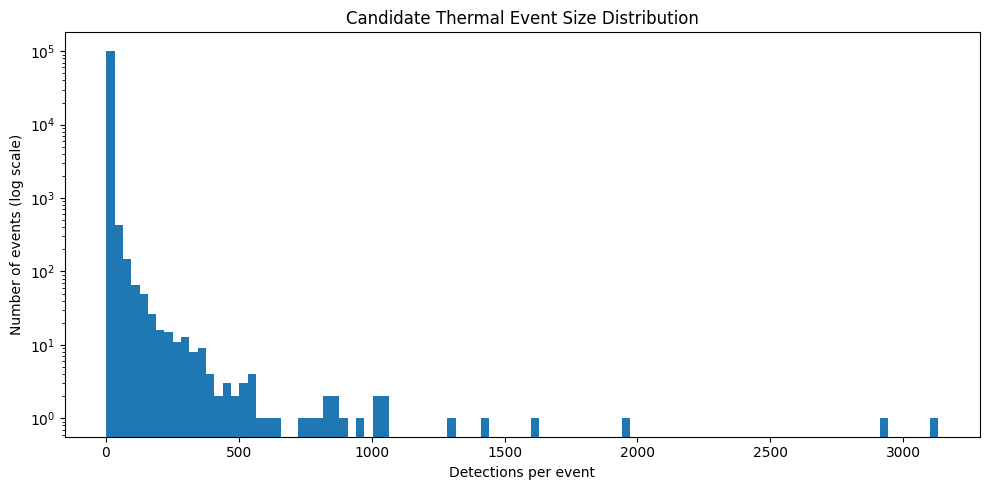

In [62]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_sizes,
    bins=100
)

plt.yscale("log")

plt.xlabel("Detections per event")
plt.ylabel("Number of events (log scale)")
plt.title("Candidate Thermal Event Size Distribution")

plt.tight_layout()
plt.show()

In [63]:
largest_events = (
    event_sizes
    .sort_values(ascending=False)
    .head(25)
)

display(largest_events)

event_id
50109    3133
167      2935
84       1973
98180    1613
46927    1414
54241    1313
63950    1057
51255    1040
50114    1027
169      1011
85        971
48311     899
50074     863
160       851
17        845
168       829
255       813
46899     764
159       737
2826      637
80        599
46985     578
50190     563
46538     552
111       548
dtype: int64

In [64]:
largest_event_id = event_sizes.idxmax()

largest_event = events[
    events["event_id"] == largest_event_id
].copy()

print("Largest event ID:", largest_event_id)
print("Detections:", len(largest_event))

print(
    "Date range:",
    largest_event["acq_date"].min(),
    "→",
    largest_event["acq_date"].max()
)

print(
    "Latitude range:",
    largest_event["latitude"].min(),
    "→",
    largest_event["latitude"].max()
)

print(
    "Longitude range:",
    largest_event["longitude"].min(),
    "→",
    largest_event["longitude"].max()
)

display(
    largest_event[
        [
            "latitude",
            "longitude",
            "acq_date",
            "frp",
            "bright_ti4",
            "bright_ti5"
        ]
    ].head(30)
)

Largest event ID: 50109
Detections: 3133
Date range: 2023-12-08 00:00:00 → 2024-03-15 00:00:00
Latitude range: 23.71428 → 23.7952
Longitude range: 86.36012 → 86.45056


,latitude,longitude,acq_date,frp,bright_ti4,bright_ti5
155982,23.7152,86.4448,2023-12-08,1.1800,299.2300,288.8000
155983,23.7154,86.4428,2023-12-08,1.0100,301.6500,288.4700
155984,23.7186,86.4503,2023-12-08,1.2600,301.0200,290.9800
155985,23.7188,86.4483,2023-12-08,3.4300,307.7600,293.3200
155986,23.7195,86.4458,2023-12-08,2.9100,303.6200,293.1500
155991,23.7466,86.4238,2023-12-08,1.3200,309.3800,289.6900
155992,23.7555,86.4024,2023-12-08,3.1300,320.9300,289.4100
155993,23.7564,86.3979,2023-12-08,2.2600,300.0300,289.4600
155995,23.7598,86.4033,2023-12-08,3.1300,331.3900,290.9800
155996,23.7607,86.3989,2023-12-08,2.2600,321.2900,291.4900


In [65]:
event_duration = (
    events
    .groupby("event_id")
    .agg(
        start_date=("acq_date", "min"),
        end_date=("acq_date", "max"),
        active_days=("acq_date", "nunique"),
        detection_count=("detection_id", "count")
    )
)

event_duration["duration_days"] = (
    event_duration["end_date"]
    - event_duration["start_date"]
).dt.days + 1

display(event_duration.describe())

,start_date,end_date,active_days,detection_count,duration_days
count,102289,102289,102289.0000,102289.0000,102289.0000
mean,2023-10-25 15:28:55.259900928,2023-10-26 10:27:51.241286656,1.5973,3.1642,1.7909
min,2023-01-01 00:00:00,2023-01-01 00:00:00,1.0000,1.0000,1.0000
25%,2023-04-01 00:00:00,2023-04-02 00:00:00,1.0000,1.0000,1.0000
50%,2023-12-21 00:00:00,2023-12-23 00:00:00,1.0000,1.0000,1.0000
75%,2024-04-18 00:00:00,2024-04-18 00:00:00,1.0000,2.0000,1.0000
max,2024-12-31 00:00:00,2024-12-31 00:00:00,160.0000,3133.0000,182.0000
std,NaN,NaN,3.7877,23.0985,4.6311


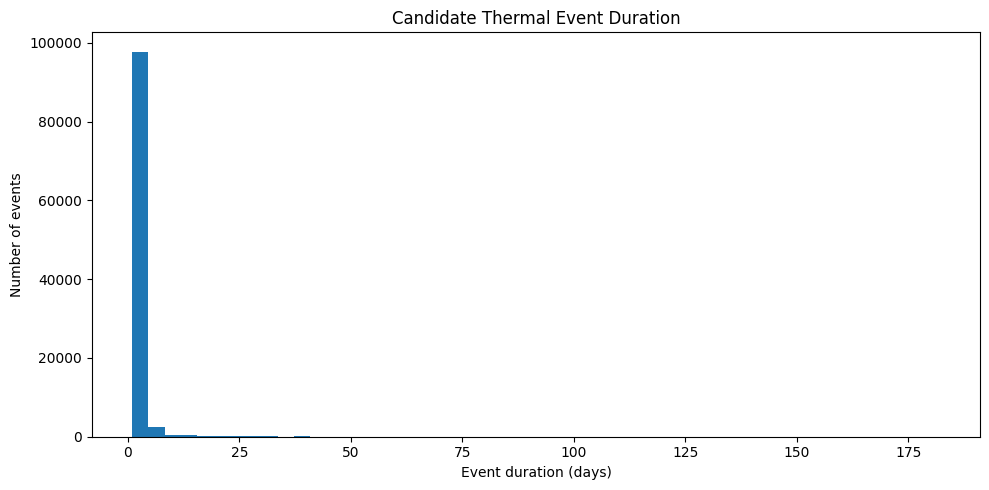

In [66]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_duration["duration_days"],
    bins=50
)

plt.xlabel("Event duration (days)")
plt.ylabel("Number of events")
plt.title("Candidate Thermal Event Duration")

plt.tight_layout()
plt.show()

In [67]:
print("Events with at least:")

for threshold in [2, 3, 5, 7, 14, 30, 60, 90]:

    count = (
        event_duration["active_days"] >= threshold
    ).sum()

    print(
        f"{threshold:>3} active days : {count:,}"
    )

Events with at least:
  2 active days : 17,510
  3 active days : 7,154
  5 active days : 3,074
  7 active days : 1,903
 14 active days : 885
 30 active days : 334
 60 active days : 87
 90 active days : 33


In [68]:
event_centroids = (
    events
    .groupby("event_id")
    .agg(
        centroid_lat=("latitude", "mean"),
        centroid_lon=("longitude", "mean")
    )
)

events_check = events.merge(
    event_centroids,
    on="event_id",
    how="left"
)

In [69]:
def haversine_km(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        2
        * EARTH_RADIUS_KM
        * np.arcsin(np.sqrt(a))
    )


events_check["distance_from_centroid_km"] = (
    haversine_km(
        events_check["latitude"],
        events_check["longitude"],
        events_check["centroid_lat"],
        events_check["centroid_lon"]
    )
)

event_extent = (
    events_check
    .groupby("event_id")
    ["distance_from_centroid_km"]
    .max()
    .rename("max_radius_km")
)

display(event_extent.describe())

count   102289.0000
mean         0.1750
std          0.3587
min          0.0000
25%          0.0000
50%          0.0000
75%          0.2257
max          8.6059
Name: max_radius_km, dtype: float64

In [70]:
display(
    event_extent
    .sort_values(ascending=False)
    .head(25)
)

event_id
72478   8.6059
25510   8.4402
26675   8.4162
9883    8.3273
98180   7.1941
74369   7.1846
50109   6.9758
29140   6.5768
27833   6.4756
9878    6.3164
25221   6.2314
4198    6.1189
30118   6.0250
63950   5.7003
75230   5.5778
77892   5.1954
27338   5.1912
10570   4.9867
8124    4.9072
19606   4.8852
72329   4.8789
31581   4.8396
167     4.8296
25532   4.8281
72861   4.8212
Name: max_radius_km, dtype: float64

In [71]:
event_summary = (
    event_duration
    .join(event_extent)
    .reset_index()
)

event_summary.to_csv(
    "viirs_event_formation_diagnostics.csv",
    index=False
)

print("Diagnostic event table saved.")

Diagnostic event table saved.


In [72]:
print("========== EVENT FORMATION SUMMARY ==========")

event_sizes = events.groupby("event_id").size()

print(f"Total detections: {len(events):,}")
print(f"Candidate events: {events['event_id'].nunique():,}")

singleton_count = (event_sizes == 1).sum()
print(f"Singleton events: {singleton_count:,}")
print(
    f"Singleton percentage: "
    f"{singleton_count / len(event_sizes) * 100:.2f}%"
)

print("\nEvent size:")
print(event_sizes.describe())

event_stats = (
    events.groupby("event_id")
    .agg(
        start_date=("acq_date", "min"),
        end_date=("acq_date", "max"),
        active_days=("acq_date", "nunique"),
        detections=("detection_id", "count"),
        centroid_lat=("latitude", "mean"),
        centroid_lon=("longitude", "mean")
    )
)

event_stats["duration_days"] = (
    event_stats["end_date"]
    - event_stats["start_date"]
).dt.days + 1

print("\nEvent duration:")
print(event_stats["duration_days"].describe())

print("\nActive days:")
print(event_stats["active_days"].describe())

print("\nLargest 20 events:")
display(
    event_sizes
    .sort_values(ascending=False)
    .head(20)
)

print("\nMost persistent 20 events:")
display(
    event_stats
    .sort_values(
        ["active_days", "detections"],
        ascending=False
    )
    .head(20)
)

========== EVENT FORMATION SUMMARY ==========
Total detections: 323,659
Candidate events: 102,289
Singleton events: 61,340
Singleton percentage: 59.97%

Event size:
count   102289.0000
mean         3.1642
std         23.0985
min          1.0000
25%          1.0000
50%          1.0000
75%          2.0000
max       3133.0000
dtype: float64

Event duration:
count   102289.0000
mean         1.7909
std          4.6311
min          1.0000
25%          1.0000
50%          1.0000
75%          1.0000
max        182.0000
Name: duration_days, dtype: float64

Active days:
count   102289.0000
mean         1.5973
std          3.7877
min          1.0000
25%          1.0000
50%          1.0000
75%          1.0000
max        160.0000
Name: active_days, dtype: float64

Largest 20 events:


event_id
50109    3133
167      2935
84       1973
98180    1613
46927    1414
54241    1313
63950    1057
51255    1040
50114    1027
169      1011
85        971
48311     899
50074     863
160       851
17        845
168       829
255       813
46899     764
159       737
2826      637
dtype: int64


Most persistent 20 events:


,start_date,end_date,active_days,detections,centroid_lat,centroid_lon,duration_days
event_id,,,,,,,
85,2023-01-01,2023-06-21,160,971,21.1070,72.6384,172
48311,2023-11-07,2024-05-06,157,899,15.1767,76.6612,182
51255,2023-12-22,2024-05-28,154,1040,21.1056,72.6400,159
169,2023-01-01,2023-06-15,148,1011,23.7884,86.3453,166
168,2023-01-01,2023-06-15,147,829,23.7773,86.2063,166
174,2023-01-01,2023-06-15,146,537,23.8053,86.3249,166
159,2023-01-01,2023-06-11,142,737,23.6783,86.0905,162
167,2023-01-01,2023-06-03,136,2935,23.7664,86.3946,154
160,2023-01-01,2023-06-03,136,851,23.6839,86.3930,154


In [73]:
def haversine_km(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2)**2
    )

    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


event_centroids = (
    events.groupby("event_id")
    .agg(
        centroid_lat=("latitude", "mean"),
        centroid_lon=("longitude", "mean")
    )
)

events_extent = events.join(
    event_centroids,
    on="event_id",
    rsuffix="_centroid"
)

events_extent["distance_from_centroid_km"] = haversine_km(
    events_extent["latitude"],
    events_extent["longitude"],
    events_extent["centroid_lat"],
    events_extent["centroid_lon"]
)

event_extent = (
    events_extent
    .groupby("event_id")["distance_from_centroid_km"]
    .max()
)

print("========== SPATIAL EXTENT ==========")
print(event_extent.describe())

print("\nLargest spatial events:")
display(
    event_extent
    .sort_values(ascending=False)
    .head(20)
)

========== SPATIAL EXTENT ==========
count   102289.0000
mean         0.1750
std          0.3587
min          0.0000
25%          0.0000
50%          0.0000
75%          0.2257
max          8.6059
Name: distance_from_centroid_km, dtype: float64

Largest spatial events:


event_id
72478   8.6059
25510   8.4402
26675   8.4162
9883    8.3273
98180   7.1941
74369   7.1846
50109   6.9758
29140   6.5768
27833   6.4756
9878    6.3164
25221   6.2314
4198    6.1189
30118   6.0250
63950   5.7003
75230   5.5778
77892   5.1954
27338   5.1912
10570   4.9867
8124    4.9072
19606   4.8852
Name: distance_from_centroid_km, dtype: float64